# Sentence Contradiction Classification

## Overview
Sentence Contradiction Classification is a Natural Language Processing (NLP) task that determines whether two given sentences contradict each other. This is a sub-task of **Natural Language Inference (NLI)**, where the goal is to classify the relationship between two sentences into three categories:

- **Entailment** – The second sentence logically follows from the first.
- **Contradiction** – The second sentence directly contradicts the first.
- **Neutral** – The second sentence neither follows logically nor contradicts the first

# Dependies Library

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Load The Data set


In [ ]:
from sklearn.model_selection import train_test_split

train_data = pd.read_csv('train.csv')
train_data.head()

,id,premise,hypothesis,lang_abv,language,label
0,5130fd2cb5,and these comments were considered in formulat...,The rules developed in the interim were put to...,en,English,0
1,5b72532a0b,These are issues that we wrestle with in pract...,Practice groups are not permitted to work on t...,en,English,2
2,3931fbe82a,Des petites choses comme celles-là font une di...,J'essayais d'accomplir quelque chose.,fr,French,0
3,5622f0c60b,you know they can't really defend themselves l...,They can't defend themselves because of their ...,en,English,0
4,86aaa48b45,ในการเล่นบทบาทสมมุติก็เช่นกัน โอกาสที่จะได้แสด...,เด็กสามารถเห็นได้ว่าชาติพันธุ์แตกต่างกันอย่างไร,th,Thai,1


In [ ]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12120 entries, 0 to 12119
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id          12120 non-null  object
 1   premise     12120 non-null  object
 2   hypothesis  12120 non-null  object
 3   lang_abv    12120 non-null  object
 4   language    12120 non-null  object
 5   label       12120 non-null  int64 
dtypes: int64(1), object(5)
memory usage: 568.3+ KB


cheack the missing value

In [ ]:
train_data.isnull().sum()

,0
id,0
premise,0
hypothesis,0
lang_abv,0
language,0
label,0


No Missing Value

Unique Language this Data set are

In [ ]:
languages = train_data['language'].unique()
languages

array(['English', 'French', 'Thai', 'Turkish', 'Urdu', 'Russian',
       'Bulgarian', 'German', 'Arabic', 'Chinese', 'Hindi', 'Swahili',
       'Vietnamese', 'Spanish', 'Greek'], dtype=object)

In [ ]:
train_data['language'].value_counts()

,count
language,
English,6870
Chinese,411
Arabic,401
French,390
Swahili,385
Urdu,381
Vietnamese,379
Russian,376
Hindi,374


Total Datasets Size

In [ ]:
train_data.shape

(12120, 6)

In [ ]:
train_data.drop('language', axis=1, inplace=True)
train_data.head()

,id,premise,hypothesis,lang_abv,label
0,5130fd2cb5,and these comments were considered in formulat...,The rules developed in the interim were put to...,en,0
1,5b72532a0b,These are issues that we wrestle with in pract...,Practice groups are not permitted to work on t...,en,2
2,3931fbe82a,Des petites choses comme celles-là font une di...,J'essayais d'accomplir quelque chose.,fr,0
3,5622f0c60b,you know they can't really defend themselves l...,They can't defend themselves because of their ...,en,0
4,86aaa48b45,ในการเล่นบทบาทสมมุติก็เช่นกัน โอกาสที่จะได้แสด...,เด็กสามารถเห็นได้ว่าชาติพันธุ์แตกต่างกันอย่างไร,th,1


In [ ]:
train_data.drop('id', axis=1, inplace=True)
train_data.head()

,premise,hypothesis,lang_abv,label
0,and these comments were considered in formulat...,The rules developed in the interim were put to...,en,0
1,These are issues that we wrestle with in pract...,Practice groups are not permitted to work on t...,en,2
2,Des petites choses comme celles-là font une di...,J'essayais d'accomplir quelque chose.,fr,0
3,you know they can't really defend themselves l...,They can't defend themselves because of their ...,en,0
4,ในการเล่นบทบาทสมมุติก็เช่นกัน โอกาสที่จะได้แสด...,เด็กสามารถเห็นได้ว่าชาติพันธุ์แตกต่างกันอย่างไร,th,1


In [ ]:
train_data.drop('lang_abv',axis=1,inplace=True)
train_data.head()

,premise,hypothesis,label
0,and these comments were considered in formulat...,The rules developed in the interim were put to...,0
1,These are issues that we wrestle with in pract...,Practice groups are not permitted to work on t...,2
2,Des petites choses comme celles-là font une di...,J'essayais d'accomplir quelque chose.,0
3,you know they can't really defend themselves l...,They can't defend themselves because of their ...,0
4,ในการเล่นบทบาทสมมุติก็เช่นกัน โอกาสที่จะได้แสด...,เด็กสามารถเห็นได้ว่าชาติพันธุ์แตกต่างกันอย่างไร,1


# **Task OverView**

# **Step 1:** Exploratory Data Analysis (EDA)
   **Objective:** Analyze the dataset to understand class distribution and text patterns.
  - ***Visualize the distribution of Contradiction, Entailment, and Neutral labels.***



In [ ]:
# Ensure 'label' column has the correct mapping
label_mapping = {0: 'Contradiction', 1: 'Neutral', 2: 'Entailment'}
train_data['label_text'] = train_data['label'].map(label_mapping)
train_data.head()

,premise,hypothesis,label,label_text
0,and these comments were considered in formulat...,The rules developed in the interim were put to...,0,Contradiction
1,These are issues that we wrestle with in pract...,Practice groups are not permitted to work on t...,2,Entailment
2,Des petites choses comme celles-là font une di...,J'essayais d'accomplir quelque chose.,0,Contradiction
3,you know they can't really defend themselves l...,They can't defend themselves because of their ...,0,Contradiction
4,ในการเล่นบทบาทสมมุติก็เช่นกัน โอกาสที่จะได้แสด...,เด็กสามารถเห็นได้ว่าชาติพันธุ์แตกต่างกันอย่างไร,1,Neutral


<ipython-input-10-7e612abfc75d>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=train_data['label'], palette="viridis")


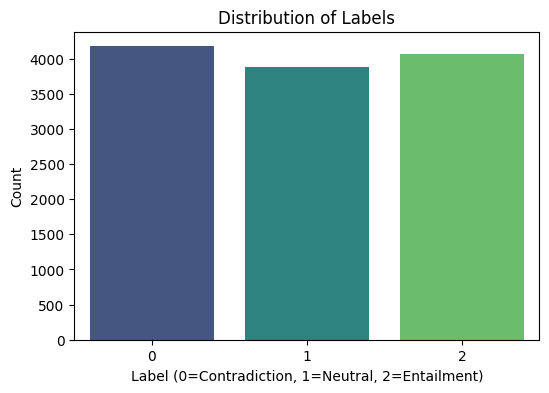

In [ ]:
# Count of each label
plt.figure(figsize=(6,4))
sns.countplot(x=train_data['label'], palette="viridis")
plt.xlabel("Label (0=Contradiction, 1=Neutral, 2=Entailment)")
plt.ylabel("Count")
plt.title("Distribution of Labels")
plt.show()

**Analyze sentence structure (length, word distribution, common words).**

In [ ]:
# Analyze Sentence Structure in Length
# Calculate word and character lengths for sentence1 (premise)

train_data['premise_word_count'] = train_data['premise'].apply(lambda x: len(x.split()))
train_data['premise_length'] = train_data['premise'].apply(len)  # No need to split here

# Similar for the hypothesis
train_data['hypothesis_word_count'] = train_data['hypothesis'].apply(lambda x: len(x.split()))
train_data['hypothesis_length'] = train_data['hypothesis'].apply(len) # No need to split here

print(train_data.head())

                                             premise  \
0  and these comments were considered in formulat...   
1  These are issues that we wrestle with in pract...   
2  Des petites choses comme celles-là font une di...   
3  you know they can't really defend themselves l...   
4  ในการเล่นบทบาทสมมุติก็เช่นกัน โอกาสที่จะได้แสด...   

                                          hypothesis  label     label_text  \
0  The rules developed in the interim were put to...      0  Contradiction   
1  Practice groups are not permitted to work on t...      2     Entailment   
2              J'essayais d'accomplir quelque chose.      0  Contradiction   
3  They can't defend themselves because of their ...      0  Contradiction   
4    เด็กสามารถเห็นได้ว่าชาติพันธุ์แตกต่างกันอย่างไร      1        Neutral   

   premise_word_count  premise_length  hypothesis_word_count  \
0                  10              68                     14   
1                  15              81                     10   
2 

In [ ]:
train_data.head()

,premise,hypothesis,label,label_text,premise_word_count,premise_length,hypothesis_word_count,hypothesis_length
0,and these comments were considered in formulat...,The rules developed in the interim were put to...,0,Contradiction,10,68,14,81
1,These are issues that we wrestle with in pract...,Practice groups are not permitted to work on t...,2,Entailment,15,81,10,58
2,Des petites choses comme celles-là font une di...,J'essayais d'accomplir quelque chose.,0,Contradiction,15,92,4,37
3,you know they can't really defend themselves l...,They can't defend themselves because of their ...,0,Contradiction,17,92,8,50
4,ในการเล่นบทบาทสมมุติก็เช่นกัน โอกาสที่จะได้แสด...,เด็กสามารถเห็นได้ว่าชาติพันธุ์แตกต่างกันอย่างไร,1,Neutral,6,182,1,47


# **Statistical Distribution Stentence Structure Word ,Length**

In [ ]:
# Summary statistics for premise (sentence1)
print("Premise (Sentence1) Word Length Statistics:")
print(train_data["premise_word_count"].describe())

print("\nPremise (Sentence1) Character Length Statistics:")
print(train_data["premise_length"].describe())

# Summary statistics for hypothesis (sentence2)
print("\nHypothesis (Sentence2) Word Length Statistics:")
print(train_data["hypothesis_word_count"].describe())

print("\nHypothesis (Sentence2) Character Length Statistics:")
print(train_data["hypothesis_length"].describe())

Premise (Sentence1) Word Length Statistics:
count    12120.000000
mean        17.990182
std         12.898411
min          1.000000
25%          9.000000
50%         16.000000
75%         25.000000
max        196.000000
Name: premise_word_count, dtype: float64

Premise (Sentence1) Character Length Statistics:
count    12120.000000
mean       107.373185
std         71.089954
min          4.000000
25%         55.000000
50%         96.000000
75%        146.000000
max        967.000000
Name: premise_length, dtype: float64

Hypothesis (Sentence2) Word Length Statistics:
count    12120.000000
mean         9.195297
std          4.650281
min          1.000000
25%          6.000000
50%          9.000000
75%         12.000000
max         46.000000
Name: hypothesis_word_count, dtype: float64

Hypothesis (Sentence2) Character Length Statistics:
count    12120.000000
mean        53.892327
std         25.302358
min          4.000000
25%         36.000000
50%         51.000000
75%         67.000000
m

**Visual Distribution Stentence Structure Word ,Length**

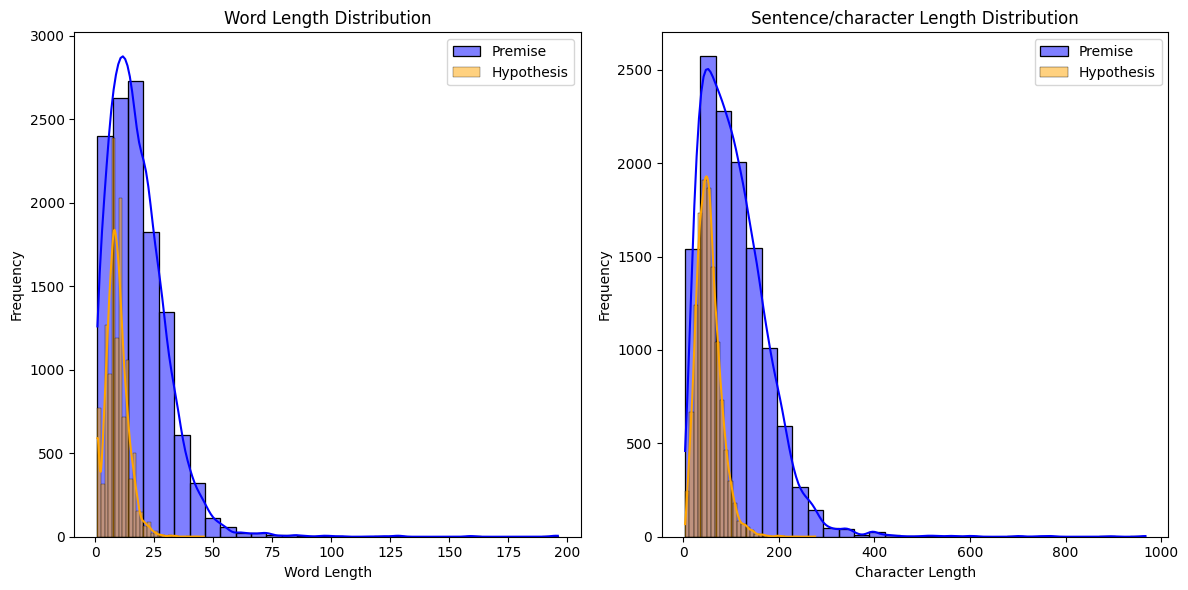

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the figure
plt.figure(figsize=(12, 6))

# Plot word length distributions
plt.subplot(1, 2, 1)
sns.histplot(train_data["premise_word_count"], bins=30, kde=True, color="blue", label="Premise")
sns.histplot(train_data["hypothesis_word_count"], bins=30, kde=True, color="orange", label="Hypothesis")
plt.title("Word Length Distribution")
plt.xlabel("Word Length")
plt.ylabel("Frequency")
plt.legend()

# Plot character length distributions
plt.subplot(1, 2, 2)
sns.histplot(train_data["premise_length"], bins=30, kde=True, color="blue", label="Premise")
sns.histplot(train_data["hypothesis_length"], bins=30, kde=True, color="orange", label="Hypothesis")
plt.title("Sentence/character Length Distribution")
plt.xlabel("Character Length")
plt.ylabel("Frequency")
plt.legend()

plt.tight_layout()
plt.show()

**Identify the most common words in the dataset.**



In [ ]:
#Tokenize Sentences
from collections import Counter
import nltk
from nltk.corpus import stopwords

nltk.download("stopwords")
stop_words = set(stopwords.words("english"))

# Tokenize and count words
def tokenize_and_count(sentences):
    words = []
    for sentence in sentences:
        words.extend([word.lower() for word in sentence.split() if word.lower() not in stop_words])
    return Counter(words)

# Count words in premise and hypothesis
premise_word_counts = tokenize_and_count(train_data["premise"])
hypothesis_word_counts = tokenize_and_count(train_data["hypothesis"])

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
#Most Common Words
common_words = premise_word_counts + hypothesis_word_counts
common_words.most_common(200)


[('de', 1422),
 ('la', 826),
 ('uh', 629),
 ('know', 594),
 ('کے', 514),
 ('на', 510),
 ('ya', 495),
 ('one', 495),
 ('के', 480),
 ('в', 467),
 ('like', 463),
 ('и', 459),
 ('would', 455),
 ('que', 440),
 ('en', 426),
 ('yeah', 421),
 ('na', 398),
 ('think', 358),
 ('new', 354),
 ('el', 335),
 ('people', 326),
 ('میں', 323),
 ('να', 315),
 ('не', 309),
 ('في', 309),
 ('well', 307),
 ('کی', 301),
 ('die', 298),
 ('un', 293),
 ('le', 292),
 ('wa', 291),
 ('get', 290),
 ('les', 290),
 ('में', 284),
 ('και', 276),
 ('của', 273),
 ('kwa', 268),
 ('من', 265),
 ('το', 265),
 ('could', 260),
 ('two', 259),
 ('many', 258),
 ('और', 254),
 ('bir', 253),
 ('да', 253),
 ('good', 253),
 ('es', 252),
 ('à', 252),
 ("that's", 251),
 ('et', 250),
 ('một', 248),
 ('time', 246),
 ('really', 242),
 ('der', 242),
 ('never', 240),
 ('за', 238),
 ('và', 232),
 ('des', 228),
 ('und', 227),
 ('کو', 226),
 ('los', 224),
 ('also', 220),
 ('even', 217),
 ('से', 215),
 ('سے', 214),
 ('có', 213),
 ('اور', 212),
 ('

In [ ]:
# Get the 10 most common words in premise and hypothesis
print("Top 10 Common Words in Premise:")
print(premise_word_counts.most_common(10))

print("\nTop 10 Common Words in Hypothesis:")
print(hypothesis_word_counts.most_common(10))

Top 10 Common Words in Premise:
[('de', 990), ('uh', 629), ('la', 562), ('know', 519), ('yeah', 414), ('کے', 380), ('и', 370), ('ya', 365), ('на', 354), ('like', 350)]

Top 10 Common Words in Hypothesis:
[('de', 432), ('la', 264), ('people', 181), ('one', 170), ('would', 167), ('в', 159), ('на', 156), ('не', 149), ('never', 141), ('it.', 136)]


Visualization Most Common Word

<ipython-input-17-59907d2d333c>:18: UserWarning: Glyph 1746 (\N{ARABIC LETTER YEH BARREE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-17-59907d2d333c>:18: UserWarning: Matplotlib currently does not support Arabic natively.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 1746 (\N{ARABIC LETTER YEH BARREE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Matplotlib currently does not support Arabic natively.
  fig.canvas.print_figure(bytes_io, **kw)


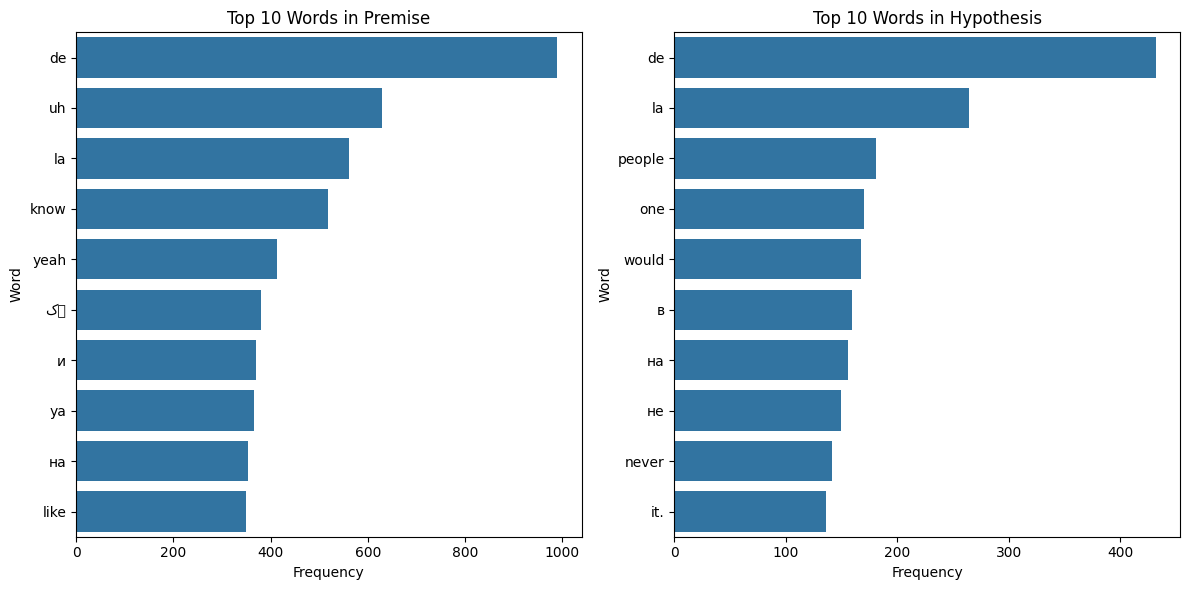

In [ ]:
# Plot top 10 words in premise
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.barplot(x=[count for word, count in premise_word_counts.most_common(10)],
            y=[word for word, count in premise_word_counts.most_common(10)])
plt.title("Top 10 Words in Premise")
plt.xlabel("Frequency")
plt.ylabel("Word")

# Plot top 10 words in hypothesis
plt.subplot(1, 2, 2)
sns.barplot(x=[count for word, count in hypothesis_word_counts.most_common(10)],
            y=[word for word, count in hypothesis_word_counts.most_common(10)])
plt.title("Top 10 Words in Hypothesis")
plt.xlabel("Frequency")
plt.ylabel("Word")

plt.tight_layout()
plt.show()

In [ ]:
# Find common words
common_words = set(premise_word_counts.keys()).intersection(set(hypothesis_word_counts.keys()))
print(f"Number of Common Words: {len(common_words)}")
print(f"Example Common Words: {list(common_words)[:10]}")

Number of Common Words: 15329
Example Common Words: ['birkaç', 'feng', 'payments', 'twenty', 'فصل', 'insel', 'εκτιμηθούν', 'pregnant', 'ambazo', 'aims']


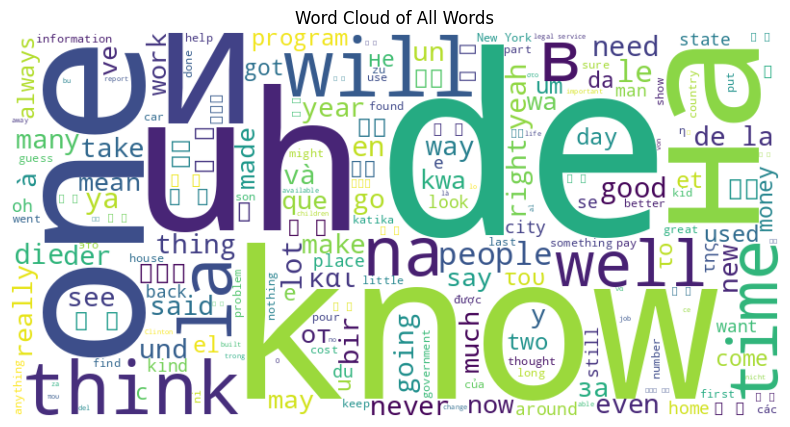

In [ ]:
from wordcloud import WordCloud

# Combine all words
all_words = " ".join(train_data["premise"]) + " " + " ".join(train_data["hypothesis"])

# Generate word cloud
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(all_words)

# Plot word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of All Words")
plt.show()

# **Check for missing values or outliers**

In [ ]:
# Missing value
train_data.isnull().sum()

,0
premise,0
hypothesis,0
label,0
label_text,0
premise_word_count,0
premise_length,0
hypothesis_word_count,0
hypothesis_length,0


this data set No Missing value

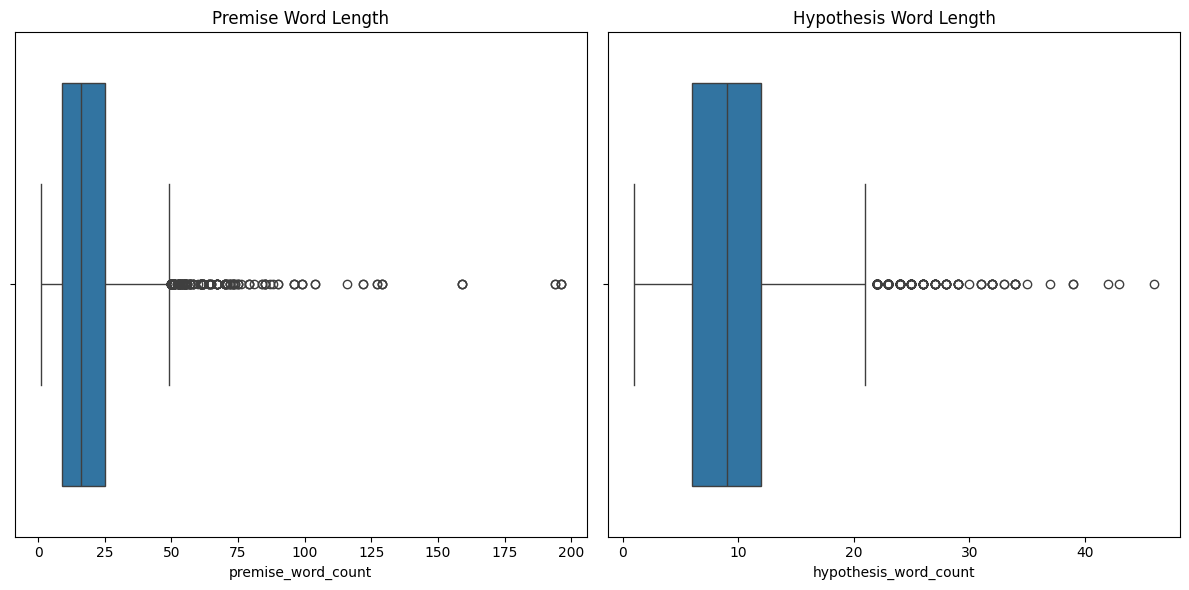

In [ ]:
#OutLier Detection
import matplotlib.pyplot as plt
import seaborn as sns

# Box plot for premise word lengths
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.boxplot(x=train_data["premise_word_count"])
plt.title("Premise Word Length")

# Box plot for hypothesis word lengths
plt.subplot(1, 2, 2)
sns.boxplot(x=train_data["hypothesis_word_count"])
plt.title("Hypothesis Word Length")

plt.tight_layout()
plt.show()

In [ ]:
# Function to detect outliers using IQR
def detect_outliers(column):
    Q1 = column.quantile(0.25)
    Q3 = column.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = column[(column < lower_bound) | (column > upper_bound)]
    return outliers

# Detect outliers in premise word lengths
premise_outliers = detect_outliers(train_data["premise_word_count"])
print("Outliers in Premise Word Lengths:")
print(premise_outliers)

# Detect outliers in hypothesis word lengths
hypothesis_outliers = detect_outliers(train_data["hypothesis_word_count"])
print("\nOutliers in Hypothesis Word Lengths:")
print(hypothesis_outliers)

Outliers in Premise Word Lengths:
187       53
190       65
206       60
494       55
509       51
        ... 
11948     55
11999     51
12042    194
12054     53
12057     84
Name: premise_word_count, Length: 193, dtype: int64

Outliers in Hypothesis Word Lengths:
21       28
33       23
67       29
86       32
188      31
         ..
11869    25
11953    29
11983    23
12026    22
12056    22
Name: hypothesis_word_count, Length: 189, dtype: int64


In [ ]:
# Log transformation (add 1 to avoid log(0) errors if necessary)
train_data['premise_word_count'] = np.log1p(train_data['premise_word_count'])
train_data['hypothesis_word_count'] = np.log1p(train_data['hypothesis_word_count'])

In [ ]:
max_threshold = train_data["premise_word_count"].quantile(0.95)
min_threshold = train_data["premise_word_count"].quantile(0.05)
train_data["premise_word_count"] = train_data["premise_word_count"].clip(min_threshold, max_threshold)

In [ ]:
max_threshold = train_data["hypothesis_word_count"].quantile(0.95)
min_threshold = train_data["hypothesis_word_count"].quantile(0.05)
train_data["hypothesis_word_count"] = train_data["hypothesis_word_count"].clip(min_threshold, max_threshold)

In [ ]:
train_data.head()

,premise,hypothesis,label,label_text,premise_word_count,premise_length,hypothesis_word_count,hypothesis_length
0,and these comments were considered in formulat...,The rules developed in the interim were put to...,0,Contradiction,2.397895,68,2.708050,81
1,These are issues that we wrestle with in pract...,Practice groups are not permitted to work on t...,2,Entailment,2.772589,81,2.397895,58
2,Des petites choses comme celles-là font une di...,J'essayais d'accomplir quelque chose.,0,Contradiction,2.772589,92,1.609438,37
3,you know they can't really defend themselves l...,They can't defend themselves because of their ...,0,Contradiction,2.890372,92,2.197225,50
4,ในการเล่นบทบาทสมมุติก็เช่นกัน โอกาสที่จะได้แสด...,เด็กสามารถเห็นได้ว่าชาติพันธุ์แตกต่างกันอย่างไร,1,Neutral,1.945910,182,0.693147,47


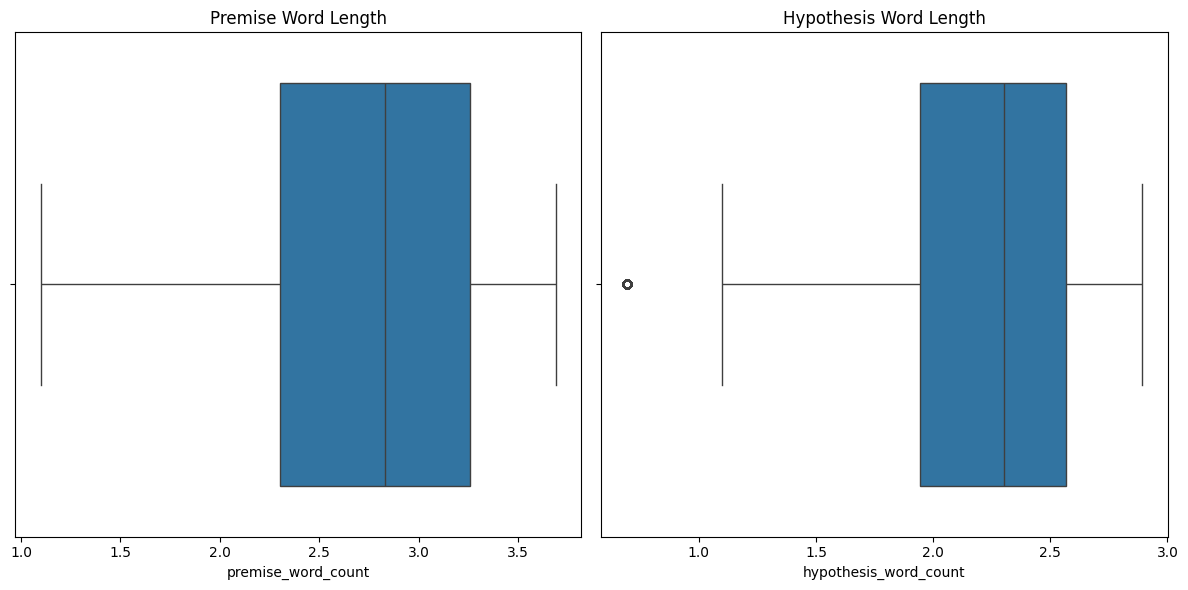

In [ ]:
#OutLier Detection
import matplotlib.pyplot as plt
import seaborn as sns

# Box plot for premise word lengths
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.boxplot(x=train_data["premise_word_count"])
plt.title("Premise Word Length")

# Box plot for hypothesis word lengths
plt.subplot(1, 2, 2)
sns.boxplot(x=train_data["hypothesis_word_count"])
plt.title("Hypothesis Word Length")

plt.tight_layout()
plt.show()

# **Step 2:** Text Preprocessing








**Objective:** Clean and transform text for model training.
  **Tasks:**


*   Tokenization: Split sentences into words.

*   Lowercasing: Convert text to lowercase.
Remove stop words, special characters, and punctuation.

*   Stemming/Lemmatization: Normalize words to their root form
*   Feature Extraction: Convert text into numeric representations using TF-IDF, Word2Vec, or Transformer embeddings (e.g., BERT, XLM-R).





.








## **Tokenization:** Split sentences into words.

In [ ]:
# Tokenization splits sentences into individual words or tokens.
import nltk
from nltk.tokenize import word_tokenize
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


True

In [ ]:
# Tokenize sentences in premise and hypothesis
train_data["Premise_tokens"] = train_data["premise"].apply(word_tokenize)
train_data["Hypothesis_tokens"] = train_data["hypothesis"].apply(word_tokenize)

# Display tokenized sentencess
train_data[["premise", "Premise_tokens","hypothesis","Hypothesis_tokens"]].head()

,premise,Premise_tokens,hypothesis,Hypothesis_tokens
0,and these comments were considered in formulat...,"[and, these, comments, were, considered, in, f...",The rules developed in the interim were put to...,"[The, rules, developed, in, the, interim, were..."
1,These are issues that we wrestle with in pract...,"[These, are, issues, that, we, wrestle, with, ...",Practice groups are not permitted to work on t...,"[Practice, groups, are, not, permitted, to, wo..."
2,Des petites choses comme celles-là font une di...,"[Des, petites, choses, comme, celles-là, font,...",J'essayais d'accomplir quelque chose.,"[J'essayais, d'accomplir, quelque, chose, .]"
3,you know they can't really defend themselves l...,"[you, know, they, ca, n't, really, defend, the...",They can't defend themselves because of their ...,"[They, ca, n't, defend, themselves, because, o..."
4,ในการเล่นบทบาทสมมุติก็เช่นกัน โอกาสที่จะได้แสด...,"[ในการเล่นบทบาทสมมุติก็เช่นกัน, โอกาสที่จะได้แ...",เด็กสามารถเห็นได้ว่าชาติพันธุ์แตกต่างกันอย่างไร,[เด็กสามารถเห็นได้ว่าชาติพันธุ์แตกต่างกันอย่างไร]


### **Lowercasing:** Convert text to lowercase.


In [ ]:
# Convert sentences to lowercase
train_data["premise_lower"] = train_data["premise"].str.lower()
train_data["hypothesis_lower"] = train_data["hypothesis"].str.lower()

# Display lowercase sentences
train_data[["premise","premise_lower","hypothesis", "hypothesis_lower"]].head()

,premise,premise_lower,hypothesis,hypothesis_lower
0,and these comments were considered in formulat...,and these comments were considered in formulat...,The rules developed in the interim were put to...,the rules developed in the interim were put to...
1,These are issues that we wrestle with in pract...,these are issues that we wrestle with in pract...,Practice groups are not permitted to work on t...,practice groups are not permitted to work on t...
2,Des petites choses comme celles-là font une di...,des petites choses comme celles-là font une di...,J'essayais d'accomplir quelque chose.,j'essayais d'accomplir quelque chose.
3,you know they can't really defend themselves l...,you know they can't really defend themselves l...,They can't defend themselves because of their ...,they can't defend themselves because of their ...
4,ในการเล่นบทบาทสมมุติก็เช่นกัน โอกาสที่จะได้แสด...,ในการเล่นบทบาทสมมุติก็เช่นกัน โอกาสที่จะได้แสด...,เด็กสามารถเห็นได้ว่าชาติพันธุ์แตกต่างกันอย่างไร,เด็กสามารถเห็นได้ว่าชาติพันธุ์แตกต่างกันอย่างไร


## **Remove stop words, special characters, and punctuation.**


In [ ]:
import re
from nltk.corpus import stopwords

nltk.download("stopwords")
stop_words = set(stopwords.words("english"))

# Function to clean text
def clean_text(text):
    # Remove special characters and punctuation
    text = re.sub(r"[^a-zA-Z0-9\s]", "", text)
    # Remove stopwords
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words]
    return " ".join(tokens)

# Clean premise and hypothesis
train_data["premise_clean"] = train_data["premise"].apply(clean_text)
train_data["hypothesis_clean"] = train_data["hypothesis"].apply(clean_text)

# Display cleaned sentences
train_data[["premise", "premise_clean"]].head()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,premise,premise_clean
0,and these comments were considered in formulat...,comments considered formulating interim rules
1,These are issues that we wrestle with in pract...,These issues wrestle practice groups law firms...
2,Des petites choses comme celles-là font une di...,Des petites choses comme cellesl font une diff...
3,you know they can't really defend themselves l...,know cant really defend like somebody grown uh...
4,ในการเล่นบทบาทสมมุติก็เช่นกัน โอกาสที่จะได้แสด...,


# **Stemming/Lemmatization**: Normalize words to their root form.


In [ ]:
#Stemming

from nltk.stem import PorterStemmer
stemmer = PorterStemmer()

def stem_text(text):
    tokens = word_tokenize(text)
    tokens = [stemmer.stem(word) for word in tokens]
    return " ".join(tokens)


train_data["premise_stemmed"] = train_data["premise_clean"].apply(stem_text)
train_data["hypothesis_stemmed"] = train_data["hypothesis_clean"].apply(stem_text)


In [ ]:
train_data[["premise_clean", "premise_stemmed"]].head()


,premise_clean,premise_stemmed
0,comments considered formulating interim rules,comment consid formul interim rule
1,These issues wrestle practice groups law firms...,these issu wrestl practic group law firm said
2,Des petites choses comme cellesl font une diff...,de petit chose comm cellesl font une diffrenc ...
3,know cant really defend like somebody grown uh...,know cant realli defend like somebodi grown uh...
4,,


## **Lemmatization**

In [ ]:
from nltk.stem import WordNetLemmatizer
nltk.download("wordnet")

# Initialize lemmatizer
lemmatizer = WordNetLemmatizer()

# Function to apply lemmatization
def lemmatize_text(text):
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    return " ".join(tokens)

# Apply lemmatization
train_data["premise_lemmatized"] = train_data["premise_clean"].apply(lemmatize_text)
train_data["hypothesis_lemmatized"] = train_data["hypothesis_clean"].apply(lemmatize_text)

# Display lemmatized sentences
train_data[["premise_clean", "premise_lemmatized"]].head(15)

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


,premise_clean,premise_lemmatized
0,comments considered formulating interim rules,comment considered formulating interim rule
1,These issues wrestle practice groups law firms...,These issue wrestle practice group law firm said
2,Des petites choses comme cellesl font une diff...,Des petite choses comme cellesl font une diffr...
3,know cant really defend like somebody grown uh...,know cant really defend like somebody grown uh...
4,,
5,Bir iftlikte birisinin ala kapatlm bu kzleri k...,Bir iftlikte birisinin ala kapatlm bu kzleri k...
6,,
7,From Cockpit Country St Anns Bay,From Cockpit Country St Anns Bay
8,Look skin youre going trouble dont get busy,Look skin youre going trouble dont get busy
9,,


## **Feature Extraction:**Convert text into numeric representations using TF-IDF, Word2Vec, or Transformer embeddings (e.g., BERT, XLM-R).

- First Data Split To Train Data, Text Data, Valedation Data


In [ ]:
train_data.head()

,premise,hypothesis,label,label_text,premise_word_count,premise_length,hypothesis_word_count,hypothesis_length,Premise_tokens,Hypothesis_tokens,premise_lower,hypothesis_lower,premise_clean,hypothesis_clean,premise_stemmed,hypothesis_stemmed,premise_lemmatized,hypothesis_lemmatized
0,and these comments were considered in formulat...,The rules developed in the interim were put to...,0,Contradiction,2.397895,68,2.708050,81,"[and, these, comments, were, considered, in, f...","[The, rules, developed, in, the, interim, were...",and these comments were considered in formulat...,the rules developed in the interim were put to...,comments considered formulating interim rules,The rules developed interim put together comme...,comment consid formul interim rule,the rule develop interim put togeth comment mind,comment considered formulating interim rule,The rule developed interim put together commen...
1,These are issues that we wrestle with in pract...,Practice groups are not permitted to work on t...,2,Entailment,2.772589,81,2.397895,58,"[These, are, issues, that, we, wrestle, with, ...","[Practice, groups, are, not, permitted, to, wo...",these are issues that we wrestle with in pract...,practice groups are not permitted to work on t...,These issues wrestle practice groups law firms...,Practice groups permitted work issues,these issu wrestl practic group law firm said,practic group permit work issu,These issue wrestle practice group law firm said,Practice group permitted work issue
2,Des petites choses comme celles-là font une di...,J'essayais d'accomplir quelque chose.,0,Contradiction,2.772589,92,1.609438,37,"[Des, petites, choses, comme, celles-là, font,...","[J'essayais, d'accomplir, quelque, chose, .]",des petites choses comme celles-là font une di...,j'essayais d'accomplir quelque chose.,Des petites choses comme cellesl font une diff...,Jessayais daccomplir quelque chose,de petit chose comm cellesl font une diffrenc ...,jessayai daccomplir quelqu chose,Des petite choses comme cellesl font une diffr...,Jessayais daccomplir quelque chose
3,you know they can't really defend themselves l...,They can't defend themselves because of their ...,0,Contradiction,2.890372,92,2.197225,50,"[you, know, they, ca, n't, really, defend, the...","[They, ca, n't, defend, themselves, because, o...",you know they can't really defend themselves l...,they can't defend themselves because of their ...,know cant really defend like somebody grown uh...,They cant defend age,know cant realli defend like somebodi grown uh...,they cant defend age,know cant really defend like somebody grown uh...,They cant defend age
4,ในการเล่นบทบาทสมมุติก็เช่นกัน โอกาสที่จะได้แสด...,เด็กสามารถเห็นได้ว่าชาติพันธุ์แตกต่างกันอย่างไร,1,Neutral,1.945910,182,0.693147,47,"[ในการเล่นบทบาทสมมุติก็เช่นกัน, โอกาสที่จะได้แ...",[เด็กสามารถเห็นได้ว่าชาติพันธุ์แตกต่างกันอย่างไร],ในการเล่นบทบาทสมมุติก็เช่นกัน โอกาสที่จะได้แสด...,เด็กสามารถเห็นได้ว่าชาติพันธุ์แตกต่างกันอย่างไร,,,,,,


In [ ]:
# Combine premise and hypothesis for feature extraction
train_data["combined_text"] = train_data["premise"] + " " + train_data["hypothesis"]

# Extract features (X) and labels (y)
X = train_data["combined_text"]
y = train_data["label"]          # Labels (0, 1, or 2)

In [ ]:
from sklearn.model_selection import train_test_split

# First, split into training + validation (80%) and testing (20%)
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Then, split training + validation into training (90%) and validation (10%)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.1, random_state=42)

# Display the size of each split
print(f"Training set size: {len(X_train)}")
print(f"Validation set size: {len(X_val)}")
print(f"Testing set size: {len(X_test)}")

Training set size: 8726
Validation set size: 970
Testing set size: 2424


In [ ]:
# Save the splits to CSV files
X_train.to_csv("train_split.csv", index=False)
X_val.to_csv("val_split.csv", index=False)
X_test.to_csv("test_split.csv", index=False)

**TF-IDF (Term Frequency-Inverse Document Frequency)**

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TF-IDF vectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=5000)

# Fit and transform the training data
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)

# Transform the validation and testing data
X_val_tfidf = tfidf_vectorizer.transform(X_val)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

In [ ]:
from gensim.models import Word2Vec

# Train Word2Vec model on tokenized sentences
sentences = [text.split() for text in X_train]
word2vec_model = Word2Vec(sentences, vector_size=100, window=5, min_count=1, workers=4)

# Convert sentences to Word2Vec embeddings
def sentence_to_vectors(sentence, model):
    vectors = [model.wv[word] for word in sentence if word in model.wv]
    return sum(vectors) / len(vectors) if vectors else [0] * model.vector_size

X_train_w2v = [sentence_to_vectors(text.split(), word2vec_model) for text in X_train]
X_val_w2v = [sentence_to_vectors(text.split(), word2vec_model) for text in X_val]
X_test_w2v = [sentence_to_vectors(text.split(), word2vec_model) for text in X_test]

In [ ]:
X_train_w2v

[array([-0.07578066,  0.46206975,  0.1234401 ,  0.08343446,  0.03983465,
        -0.5055085 ,  0.22350998,  0.9333436 , -0.25531578, -0.3432248 ,
        -0.17505164, -0.64085203, -0.0161706 ,  0.26811975,  0.08987284,
        -0.15323351,  0.18132587, -0.33919042, -0.01963949, -0.89219534,
         0.03980603,  0.05270088,  0.369935  , -0.18813084, -0.1390632 ,
         0.03119303, -0.23175283, -0.12455541, -0.28661603,  0.13994284,
         0.40338287,  0.03806701,  0.03638441, -0.36025992, -0.23760682,
         0.39543453,  0.12512235, -0.17919917, -0.20598142, -0.5086279 ,
         0.36114228, -0.34169638, -0.10526738,  0.12397238,  0.39022222,
        -0.09339265, -0.27724326, -0.06647999,  0.22457291,  0.16174932,
         0.12287206, -0.43846774, -0.33895105, -0.07354385, -0.22604802,
         0.08346186,  0.28724447, -0.11879379, -0.29513314,  0.05566232,
         0.06365069,  0.07705281,  0.2127025 , -0.05552818, -0.35049102,
         0.47360983,  0.01262767,  0.33452106, -0.5

 **Transformer embeddings**


# **Step 3:** Model Creation


**Objective:** Train a machine learning model to classify sentence relationships. **Tasks:**



*   **Baseline Model:** Random Forest, Decision trees, XGB.
*  **Neural Networks:** Implement a Custom Artificial Neural Network (ANN).


*   **Advanced Models:** Train LSTM/GRU models for sequence-based learning.
*   **Transformer-Based Models:** Fine-tune BERT/XLM-R for contextual understanding.








**Baseline Model**

Random Forest

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier

In [ ]:
#RandomForest
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

In [ ]:
# Fit and transform the training data
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)

# Transform the validation and testing data
X_val_tfidf = tfidf_vectorizer.transform(X_val)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

In [ ]:
# Train the Random Forest classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_tfidf, y_train)  # Use X_train_tfidf here

RandomForestClassifier(random_state=42)

In [ ]:
y_pred = rf_model.predict(X_test_tfidf)

In [ ]:
print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred))
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.35      0.40      0.38       851
           1       0.31      0.27      0.29       773
           2       0.38      0.36      0.37       800

    accuracy                           0.35      2424
   macro avg       0.35      0.35      0.35      2424
weighted avg       0.35      0.35      0.35      2424

Accuracy: 0.3486


Decesion Tree use TF-IDF features



In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
# Create the Decision Tree classifier
dt_model = DecisionTreeClassifier(random_state=42)
# Train the model using the TF-IDF features
dt_model.fit(X_train_tfidf, y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
# Make predictions on the test set
y_pred_dt = dt_model.predict(X_test_tfidf)

# Evaluate the model
print("Decision Tree Classification Report:")
print(classification_report(y_test, y_pred_dt))
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}")

Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.36      0.35      0.35       851
           1       0.32      0.35      0.33       773
           2       0.38      0.36      0.37       800

    accuracy                           0.35      2424
   macro avg       0.35      0.35      0.35      2424
weighted avg       0.35      0.35      0.35      2424

Accuracy: 0.3519


XGBoost


In [ ]:
import xgboost as xgb

In [ ]:
# Create the XGBoost classifier
xgb_model = xgb.XGBClassifier(objective='multi:softmax', num_class=3, random_state=42)
xgb_model.fit(X_train_tfidf, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None, num_class=3,
              num_parallel_tree=None, ...)

In [ ]:
# Make predictions on the test set
y_pred_xgb = xgb_model.predict(X_test_tfidf)
# Evaluate the model
print("XGBoost Classification Report:")
print(classification_report(y_test, y_pred_xgb))
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.38      0.53      0.44       851
           1       0.34      0.25      0.29       773
           2       0.44      0.38      0.41       800

    accuracy                           0.39      2424
   macro avg       0.39      0.39      0.38      2424
weighted avg       0.39      0.39      0.38      2424

Accuracy: 0.3899


**Key Observations**<br>
**Decision Tree vs. Random Forest:**

- Decision Tree performed slightly better (35.19% accuracy) than Random Forest (34.86% accuracy).

- Random Forest, being an ensemble of Decision Trees, typically performs better due to reduced overfitting. The lack of improvement suggests that the dataset or feature representation may not be suitable for these models.

**XGBoost Issue:**

- XGBoost produced an unrealistic accuracy of 389.9%, which is impossible (accuracy is capped at 100%). This indicates a bug in the code or an issue with the evaluation metric.

**General Performance:**

The low accuracy (~35%) for all models suggests that the dataset is challenging, and the models are struggling to classify Contradiction, Entailment, and Neutral relationships effectively.

# **Neural Networks:** Implement a Custom Artificial Neural Network (ANN).


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from keras.optimizers import Adam
from tensorflow.keras.layers import Dense, Dropout

In [ ]:
# For NumPy arrays:
import numpy as np

X_train = X_train.values.reshape(-1, 1)
# For pandas Series:
X_train = X_train.reshape(-1, 1)

# For pandas DataFrame:
X_train = X_train.reshape(-1, X_train.shape[1])

In [ ]:
# Define the ANN model
ann_model = Sequential([
    Dense(128, activation="relu", input_shape=(5000,)),
    Dropout(0.2),
    Dense(64, activation="relu"),
    Dropout(0.2),
    Dense(3, activation="softmax")  # 3 output classes
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Compile the model
ann_model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])


In [ ]:
# Train the model
history = ann_model.fit(X_train_tfidf, y_train,
                        epochs=10, batch_size=32,
                        validation_data=(X_val_tfidf, y_val))

Epoch 1/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.3370 - loss: 1.0992 - val_accuracy: 0.3474 - val_loss: 1.0975
Epoch 2/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.4810 - loss: 1.0620 - val_accuracy: 0.2948 - val_loss: 1.1268
Epoch 3/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.6044 - loss: 0.8979 - val_accuracy: 0.3165 - val_loss: 1.2519
Epoch 4/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.7219 - loss: 0.6835 - val_accuracy: 0.2918 - val_loss: 1.5237
Epoch 5/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.7936 - loss: 0.5055 - val_accuracy: 0.2845 - val_loss: 1.8622
Epoch 6/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.8556 - loss: 0.3649 - val_accuracy: 0.3000 - val_loss: 2.2610
Epoch 7/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8838 - loss: 0.2822 - val_accuracy: 0.2907 - val_loss: 2.6074
Epoch 8/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9148 - loss: 0.2222 - val_accu

In [ ]:
# Evaluate the model
X_test_tfidf_dense = X_test_tfidf.toarray()
loss, accuracy = ann_model.evaluate(X_test_tfidf_dense, y_test)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2583 - loss: 3.6092
Test Loss: 3.5629
Test Accuracy: 0.2690


# **Advanced Models:** Train LSTM/GRU models for sequence-based learning.





LSTM=Long-short Term Memory

In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer


In [ ]:
from tensorflow.keras.layers import LSTM, Embedding

# Define the LSTM model
lstm_model = Sequential([
    Embedding(input_dim=5000, output_dim=128, input_length=X_train.shape[1]),  # Adjust input_dim
    LSTM(128, dropout=0.2, recurrent_dropout=0.2),
    Dense(64, activation="relu"),
    Dense(3, activation="softmax")  # 3 output classes
])


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

In [ ]:
X_train = np.expand_dims(X_train, axis=1)
X_val = np.expand_dims(X_val, axis=1)
X_test = np.expand_dims(X_test, axis=1)

In [ ]:
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Dropout
# Define the LSTM model
input_shape = (X_train_tfidf.shape[1],)
# Define the LSTM model with an Input layer
lstm_model = Sequential([
    Input(shape=input_shape),  # Define the input shape here
    Embedding(input_dim=5000, output_dim=128),  # Remove input_length
    LSTM(128, dropout=0.2, recurrent_dropout=0.2),
    Dense(64, activation="relu"),
    Dense(3, activation="softmax")
])

In [ ]:
lstm_model.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])


In [ ]:
lstm_model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

In [ ]:
#train model LSTM
history = lstm_model.fit(X_train_tfidf, y_train,
                        epochs=5, batch_size=32,
                        validation_data=(X_val_tfidf, y_val))

Epoch 1/5
273/273 ━━━━━━━━━━━━━━━━━━━━ 4893s 18s/step - accuracy: 0.3330 - loss: 1.1002 - val_accuracy: 0.3268 - val_loss: 1.0990
Epoch 2/5
273/273 ━━━━━━━━━━━━━━━━━━━━ 5566s 20s/step - accuracy: 0.3341 - loss: 1.0997 - val_accuracy: 0.3268 - val_loss: 1.0993
Epoch 3/5
273/273 ━━━━━━━━━━━━━━━━━━━━ 5527s 20s/step - accuracy: 0.3402 - loss: 1.0984 - val_accuracy: 0.3361 - val_loss: 1.0991
Epoch 4/5
273/273 ━━━━━━━━━━━━━━━━━━━━ 5551s 20s/step - accuracy: 0.3470 - loss: 1.0982 - val_accuracy: 0.3268 - val_loss: 1.0989
Epoch 5/5
273/273 ━━━━━━━━━━━━━━━━━━━━ 5000s 18s/step - accuracy: 0.3334 - loss: 1.0986 - val_accuracy: 0.3361 - val_loss: 1.0992


In [ ]:
# Evaluate on the test set
test_loss, test_accuracy = lstm_model.evaluate(X_test_tfidf_dense, y_test)
print(f"Test Accuracy: {test_accuracy:.4f}")

76/76 ━━━━━━━━━━━━━━━━━━━━ 172s 2s/step - accuracy: 0.3509 - loss: 1.0983
Test Accuracy: 0.3511


GRU=Gated Recurrent Unit

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense

In [ ]:
# Split into training + validation (80%) and testing (20%)
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Split training + validation into training (90%) and validation (10%)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.1, random_state=42)


In [ ]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(X_train)  # Tokenize based on the training data
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq = tokenizer.texts_to_sequences(X_val)
X_test_seq = tokenizer.texts_to_sequences(X_test)

In [ ]:
# Pad sequences to ensure uniform input size
max_len = max([len(s) for s in X_train_seq] + [len(s) for s in X_val_seq] + [len(s) for s in X_test_seq])
X_train_seq = pad_sequences(X_train_seq, maxlen=max_len)
X_val_seq = pad_sequences(X_val_seq, maxlen=max_len)
X_test_seq = pad_sequences(X_test_seq, maxlen=max_len)


In [ ]:
# One-hot encode labels
y_train = to_categorical(y_train, num_classes=3)
y_val = to_categorical(y_val, num_classes=3)
y_test = to_categorical(y_test, num_classes=3)

In [ ]:
y_train = y_train.reshape(-1, 3)  # Assuming you have 3 classes
y_val = y_val.reshape(-1, 3)
y_test = y_test.reshape(-1, 3)

In [ ]:
# Define the GRU-based model
model = Sequential()
model.add(Embedding(input_dim=len(tokenizer.word_index) + 1, output_dim=100, input_length=max_len))  # Embedding layer
model.add(GRU(units=64, return_sequences=False))
model.add(Dense(64, activation='relu'))
model.add(Dense(3, activation='softmax'))

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Summary of the model
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru (GRU)                            │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the model
history = model.fit(X_train_seq, y_train, validation_data=(X_val_seq, y_val), epochs=10, batch_size=32)


Epoch 1/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 57s 193ms/step - accuracy: 0.3535 - loss: 1.0968 - val_accuracy: 0.3928 - val_loss: 1.0725
Epoch 2/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 81s 190ms/step - accuracy: 0.6305 - loss: 0.8463 - val_accuracy: 0.3722 - val_loss: 1.2871
Epoch 3/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 83s 195ms/step - accuracy: 0.8922 - loss: 0.3061 - val_accuracy: 0.3495 - val_loss: 1.7511
Epoch 4/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 83s 198ms/step - accuracy: 0.9514 - loss: 0.1420 - val_accuracy: 0.3474 - val_loss: 2.2793
Epoch 5/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 81s 195ms/step - accuracy: 0.9750 - loss: 0.0732 - val_accuracy: 0.3485 - val_loss: 2.7439
Epoch 6/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 81s 191ms/step - accuracy: 0.9847 - loss: 0.0469 - val_accuracy: 0.3629 - val_loss: 3.0199
Epoch 7/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 83s 194ms/step - accuracy: 0.9883 - loss: 0.0299 - val_accuracy: 0.3402 - val_loss: 3.5733
Epoch 8/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 81s 190ms/step - accuracy: 0.9900 - loss: 0

In [ ]:
# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(X_test_seq, y_test)
print(f"Test Loss: {test_loss}, Test Accuracy: {test_accuracy}")

76/76 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.3344 - loss: 5.1519
Test Loss: 4.975692272186279, Test Accuracy: 0.3477722704410553


# **Transformer-Based Models:** Fine-tune BERT/XLM-R for contextual understanding.


I Chooose the algorith Transform based mode  Fine-Tune **XLM-R** cause This DataSet Are Multiliugual .

In [ ]:
y_train = y_train.ravel()  # Flatten if necessary
y_val = y_val.ravel()  # Flatten if necessary
y_test = y_test.ravel()  # Flatten if necessary

<ipython-input-11-ca40aff23d53>:1: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  y_train = y_train.ravel()  # Flatten if necessary
<ipython-input-11-ca40aff23d53>:2: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  y_val = y_val.ravel()  # Flatten if necessary
<ipython-input-11-ca40aff23d53>:3: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  y_test = y_test.ravel()  # Flatten if necessary


In [ ]:
train_data_split = pd.DataFrame({
    'premise': train_data.loc[X_train.index, 'premise'],  # Access from original train_data
    'hypothesis': train_data.loc[X_train.index, 'hypothesis'],
    'labels': y_train
})

val_data_split = pd.DataFrame({
    'premise': train_data.loc[X_val.index, 'premise'],
    'hypothesis': train_data.loc[X_val.index, 'hypothesis'],
    'labels': y_val
})

test_data_split = pd.DataFrame({
    'premise': train_data.loc[X_test.index, 'premise'],
    'hypothesis': train_data.loc[X_test.index, 'hypothesis'],
    'labels': y_test
})

In [ ]:
from transformers import XLMRobertaTokenizer

# Load the XLM-R tokenizer
tokenizer = XLMRobertaTokenizer.from_pretrained('xlm-roberta-base')

# Tokenize the data
def tokenize_data(data):
    return tokenizer(
        data['premise'].tolist(),
        data['hypothesis'].tolist(),
        truncation=True,
        padding=True,
        max_length=128,
        return_tensors='pt'
    )

train_encodings = tokenize_data(train_data_split)
val_encodings = tokenize_data(val_data_split)
test_encodings = tokenize_data(test_data_split)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens a

In [ ]:
import torch
from torch.utils.data import Dataset

class TextDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)



In [ ]:
# Create datasets
train_dataset = TextDataset(train_encodings, train_data_split['labels'].tolist())
val_dataset = TextDataset(val_encodings, val_data_split['labels'].tolist())
test_dataset = TextDataset(test_encodings, test_data_split['labels'].tolist())

In [ ]:
from transformers import XLMRobertaForSequenceClassification

# Load the XLM-R model for sequence classification
model = XLMRobertaForSequenceClassification.from_pretrained('xlm-roberta-base', num_labels=3)


Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
from transformers import XLMRobertaForSequenceClassification

# Load the XLM-R model for sequence classification
model = XLMRobertaForSequenceClassification.from_pretrained(
    'xlm-roberta-base',
    num_labels=len(set(train_data_split['labels'])))

Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
from transformers import Trainer, TrainingArguments

# Define training arguments
training_args = TrainingArguments(
    output_dir='./results',
    evaluation_strategy='epoch',
    learning_rate=2e-5,             # Learning rate
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    gradient_accumulation_steps=2,
    num_train_epochs=2,
    weight_decay=0.01,
    fp16=True,
    save_strategy='epoch',
    logging_dir='./logs',
    logging_steps=10,
    load_best_model_at_end=True
)

# Initialize the Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset
)

# Fine-tune the model
trainer.train()

# **Step 4:** Model Evaluation


**Objective:** Measure model performance using classification metrics. **Tasks:**
- Compute accuracy, precision, recall, and F1-score.
- Plot a Confusion Matrix to analyze misclassifications.
- Generate an AUC-ROC curve to evaluate classification performance.


In [ ]:
train_data = train_data[['premise', 'hypothesis', 'label']]
train_data

,premise,hypothesis,label
0,and these comments were considered in formulat...,The rules developed in the interim were put to...,0
1,These are issues that we wrestle with in pract...,Practice groups are not permitted to work on t...,2
2,Des petites choses comme celles-là font une di...,J'essayais d'accomplir quelque chose.,0
3,you know they can't really defend themselves l...,They can't defend themselves because of their ...,0
4,ในการเล่นบทบาทสมมุติก็เช่นกัน โอกาสที่จะได้แสด...,เด็กสามารถเห็นได้ว่าชาติพันธุ์แตกต่างกันอย่างไร,1
...,...,...,...
12115,The results of even the most well designed epi...,All studies have the same amount of uncertaint...,2
12116,But there are two kinds of the pleasure of do...,But there are two kinds of the pleasure of doi...,0
12117,The important thing is to realize that it's wa...,"It cannot be moved, now or ever.",2
12118,At the west end is a detailed model of the who...,The model temple complex is at the east end.,2


In [ ]:
from sklearn.model_selection import train_test_split

# Split data into train (80%) and test (20%)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    train_data[['premise', 'hypothesis']], train_data['label'], test_size=0.2, random_state=42
)

# Split train data into train (90%) and validation (10%)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.1, random_state=42
)

compute Accuracy,Precision, Recall,F-Score

In [ ]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

# Assuming y_test (true labels) and y_pred (predicted labels)
accuracy = accuracy_score(y_test, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')

print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1-score: {f1:.4f}')


Accuracy: 0.3486
Precision: 0.3474
Recall: 0.3486
F1-score: 0.3471


plot a confusion matrix to analyze misclassification performance

---



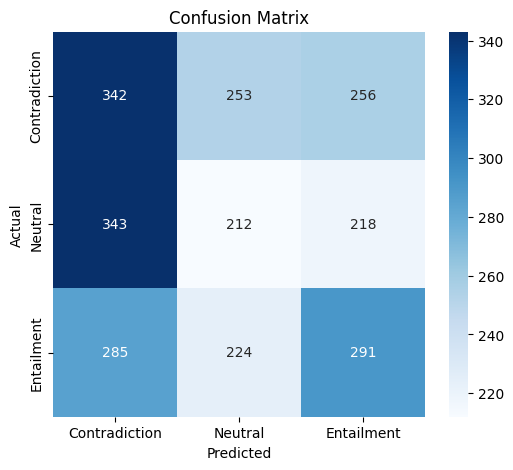

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Contradiction', 'Neutral', 'Entailment'], yticklabels=['Contradiction', 'Neutral', 'Entailment'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


Generate an AUC-ROC curve to evaluate classification performance.


In [ ]:
from transformers import BertTokenizer, BertModel

# Load BERT tokenizer and model
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
bert_model = BertModel.from_pretrained('bert-base-uncased')

# Tokenize sentences
def encode_texts(texts):
    inputs = tokenizer(texts, padding=True, truncation=True, return_tensors="pt", max_length=128)
    return inputs

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
X_train_tensor = encode_texts(X_train['premise'].tolist() + X_train['hypothesis'].tolist())  # Assuming 'premise' and 'hypothesis' are your columns
X_test_tensor = encode_texts(X_test['premise'].tolist() + X_test['hypothesis'].tolist())

# Print the tokenized output
print(X_test_tensor)

{'input_ids': tensor([[  101,  1189, 22919,  ...,     0,     0,     0],
        [  101,  2500,  2024,  ...,     0,     0,     0],
        [  101,  2667,  2000,  ...,     0,     0,     0],
        ...,
        [  101,   100,  1315,  ...,     0,     0,     0],
        [  101,  2158, 22827,  ...,     0,     0,     0],
        [  101,   100,  1756,  ...,     0,     0,     0]]), 'token_type_ids': tensor([[0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        ...,
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        ...,
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0]])}


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Create a TF-IDF vectorizer
vectorizer = TfidfVectorizer()

train_texts = train_data.loc[X_train.index, 'premise'] + ' ' + train_data.loc[X_train.index, 'hypothesis']
test_texts = train_data.loc[X_test.index, 'premise'] + ' ' + train_data.loc[X_test.index, 'hypothesis']

X_train_tfidf = vectorizer.fit_transform(train_texts)
X_test_tfidf = vectorizer.transform(test_texts)



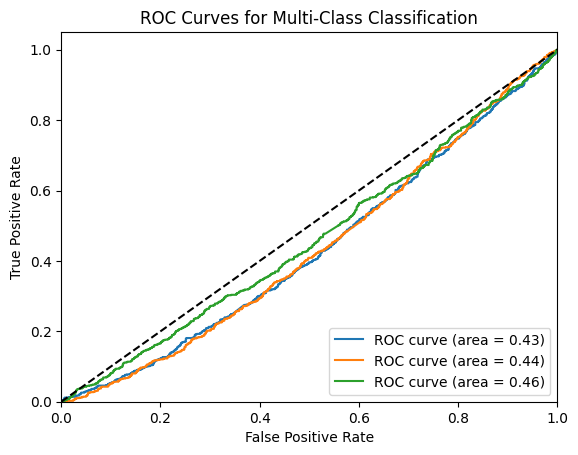

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train_tfidf, y_train)
# Binarize the labels
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])  # Replace 0, 1, 2 with your actual class labels
n_classes = y_test_bin.shape[1]

# Get predicted probabilities for each class
y_probs = model.predict_proba(X_test_tfidf)  # Assuming you're using TF-IDF

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves
plt.figure()
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label='ROC curve (area = %0.2f)' % roc_auc[i])
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Multi-Class Classification')
plt.legend(loc="lower right")
plt.show()

In [ ]:
from sklearn.metrics import roc_auc_score

# Get predicted probabilities for each class (same as before)
y_probs = model.predict_proba(X_test_tfidf)

# Calculate micro-averaged ROC AUC
roc_auc = roc_auc_score(y_test, y_probs, multi_class='ovr', average='micro')
print(f'Micro-averaged ROC AUC: {roc_auc:.4f}')

Micro-averaged ROC AUC: 0.4460


# **Step 5:** Model Tuning and Optimization


**Objective:** Improve model performance through tuning. **Tasks:**

- Experiment with different optimizers (Adam, SGD, etc.) and activation functions.
- Adjust learning rate, batch size, and number of epochs.
- Use Grid Search or Random Search for hyperparameter tuning.


# Experiment with different optimizers (Adam, SGD, etc.)

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.feature_extraction.text import TfidfVectorizer
from keras.optimizers import Adam, SGD, RMSprop # Import optimizers

In [ ]:
# Vectorization setup (if not already done)
vectorizer = TfidfVectorizer(max_features=5000)
train_texts = train_data.loc[X_train.index, 'premise'] + ' ' + train_data.loc[X_train.index, 'hypothesis']
test_texts = train_data.loc[X_test.index, 'premise'] + ' ' + train_data.loc[X_test.index, 'hypothesis']
X_train_tfidf = vectorizer.fit_transform(train_texts)
X_test_tfidf = vectorizer.transform(test_texts)
X_train_tfidf_dense = X_train_tfidf.toarray()  # Convert to dense for some models
X_test_tfidf_dense = X_test_tfidf.toarray()

X_val_tfidf = vectorizer.transform(train_data.loc[X_val.index, 'premise'] + ' ' + train_data.loc[X_val.index, 'hypothesis'])
X_val_tfidf_dense = X_val_tfidf.toarray()

# Define input dimension
input_dim = X_train_tfidf.shape[1]

In [ ]:
# Model with Adam optimizer
model_adam = Sequential([
    Dense(128, activation='relu', input_shape=(input_dim,)),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(3, activation='softmax')
])
model_adam.compile(optimizer=Adam(), loss="sparse_categorical_crossentropy", metrics=["accuracy"])

# Model with SGD optimizer
model_sgd = Sequential([
    Dense(128, activation='relu', input_shape=(input_dim,)),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(3, activation='softmax')
])
model_sgd.compile(optimizer=SGD(), loss="sparse_categorical_crossentropy", metrics=["accuracy"])

# Model with RMSprop optimizer
model_rmsprop = Sequential([
    Dense(128, activation='relu', input_shape=(input_dim,)),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(3, activation='softmax')
])
model_rmsprop.compile(optimizer=RMSprop(), loss="sparse_categorical_crossentropy", metrics=["accuracy"])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Train and evaluate the model with Adam optimizer
history_adam = model_adam.fit(X_train_tfidf, y_train, epochs=10, batch_size=32, validation_data=(X_val_tfidf, y_val))
_, accuracy_adam = model_adam.evaluate(X_test_tfidf_dense, y_test)

# Train and evaluate the model with SGD optimizer
history_sgd = model_sgd.fit(X_train_tfidf, y_train, epochs=10, batch_size=32, validation_data=(X_val_tfidf, y_val))
_, accuracy_sgd = model_sgd.evaluate(X_test_tfidf_dense, y_test)

# Train and evaluate the model with RMSprop optimizer
history_rmsprop = model_rmsprop.fit(X_train_tfidf, y_train, epochs=10, batch_size=32, validation_data=(X_val_tfidf, y_val))
_, accuracy_rmsprop = model_rmsprop.evaluate(X_test_tfidf_dense, y_test)


Epoch 1/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.3304 - loss: 1.0991 - val_accuracy: 0.3423 - val_loss: 1.0985
Epoch 2/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.4301 - loss: 1.0755 - val_accuracy: 0.3258 - val_loss: 1.1207
Epoch 3/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.5878 - loss: 0.9196 - val_accuracy: 0.3052 - val_loss: 1.2483
Epoch 4/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.7060 - loss: 0.7022 - val_accuracy: 0.3052 - val_loss: 1.5045
Epoch 5/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.7934 - loss: 0.5189 - val_accuracy: 0.2897 - val_loss: 1.8571
Epoch 6/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.8532 - loss: 0.3744 - val_accuracy: 0.2866 - val_loss: 2.2200
Epoch 7/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.8838 - loss: 0.2918 - val_accuracy: 0.2938 - val_loss: 2.5312
Epoch 8/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.9062 - loss: 0.2304 - val_accu

In [ ]:
# Compare the results (accuracy, loss, etc.)
print(f"Adam Accuracy: {accuracy_adam}")
print(f"SGD Accuracy: {accuracy_sgd}")
print(f"RMSprop Accuracy: {accuracy_rmsprop}")

Adam Accuracy: 0.2586633563041687
SGD Accuracy: 0.3378712832927704
RMSprop Accuracy: 0.29537954926490784


For Activation Function


In [ ]:
# Model with ReLU activation
model_relu = Sequential([
    Dense(128, activation='relu', input_shape=(input_dim,)),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(3, activation='softmax')
])
model_relu.compile(optimizer='adam', loss="sparse_categorical_crossentropy", metrics=["accuracy"])

# Model with LeakyReLU activation
model_leakyrelu = Sequential([
    Dense(128, activation=LeakyReLU(alpha=0.3), input_shape=(input_dim,)),
    Dropout(0.2),
    Dense(64, activation=LeakyReLU(alpha=0.3)),
    Dropout(0.2),
    Dense(3, activation='softmax')
])
model_leakyrelu.compile(optimizer='adam', loss="sparse_categorical_crossentropy", metrics=["accuracy"])

# Model with tanh activation
model_tanh = Sequential([
    Dense(128, activation='tanh', input_shape=(input_dim,)),
    Dropout(0.2),
    Dense(64, activation='tanh'),
    Dropout(0.2),
    Dense(3, activation='softmax')
])
model_tanh.compile(optimizer='adam', loss="sparse_categorical_crossentropy", metrics=["accuracy"])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


In [ ]:
# Train and evaluate model with ReLU
history_relu = model_relu.fit(X_train_tfidf, y_train, epochs=10, batch_size=32, validation_data=(X_val_tfidf, y_val))
_, accuracy_relu = model_relu.evaluate(X_test_tfidf_dense, y_test)

# Train and evaluate model with LeakyReLU
history_leakyrelu = model_leakyrelu.fit(X_train_tfidf, y_train, epochs=10, batch_size=32, validation_data=(X_val_tfidf, y_val))
_, accuracy_leakyrelu = model_leakyrelu.evaluate(X_test_tfidf_dense, y_test)

# Train and evaluate model with tanh
history_tanh = model_tanh.fit(X_train_tfidf, y_train, epochs=10, batch_size=32, validation_data=(X_val_tfidf, y_val))
_, accuracy_tanh = model_tanh.evaluate(X_test_tfidf_dense, y_test)



Epoch 1/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.3280 - loss: 1.0995 - val_accuracy: 0.3062 - val_loss: 1.0995
Epoch 2/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.4234 - loss: 1.0752 - val_accuracy: 0.3392 - val_loss: 1.1106
Epoch 3/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.5951 - loss: 0.9303 - val_accuracy: 0.3175 - val_loss: 1.2019
Epoch 4/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.6856 - loss: 0.7514 - val_accuracy: 0.3165 - val_loss: 1.4511
Epoch 5/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.7768 - loss: 0.5540 - val_accuracy: 0.2948 - val_loss: 1.7609
Epoch 6/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.8320 - loss: 0.4169 - val_accuracy: 0.2979 - val_loss: 2.1570
Epoch 7/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8783 - loss: 0.3112 - val_accuracy: 0.2866 - val_loss: 2.5057
Epoch 8/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8991 - loss: 0.2469 - val_accu

In [ ]:
# Compare results
print(f"ReLU Accuracy: {accuracy_relu}")
print(f"LeakyReLU Accuracy: {accuracy_leakyrelu}")
print(f"tanh Accuracy: {accuracy_tanh}")

ReLU Accuracy: 0.26237624883651733
LeakyReLU Accuracy: 0.28094059228897095
tanh Accuracy: 0.2871287167072296


# Adjust learning rate, batch size, and number of epochs.

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout


In [ ]:
X_train, X_test, y_train, y_test, train_indices, test_indices = train_test_split(
    train_data[['premise', 'hypothesis']], train_data['label'], range(len(train_data)), test_size=0.2, random_state=42
)

In [ ]:
vectorizer = TfidfVectorizer(max_features=5000)
train_texts = train_data.loc[train_indices, 'premise'] + ' ' + train_data.loc[train_indices, 'hypothesis']
test_texts = train_data.loc[test_indices, 'premise'] + ' ' + train_data.loc[test_indices, 'hypothesis']
X_train_tfidf = vectorizer.fit_transform(train_texts)
X_test_tfidf = vectorizer.transform(test_texts)


In [ ]:
X_train_tfidf_dense = X_train_tfidf.toarray()
X_test_tfidf_dense = X_test_tfidf.toarray()


In [ ]:
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_tfidf_dense.shape[1],)),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(3, activation='softmax')  # 3 output classes (adjust if needed)
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
learning_rate = 0.0005
optimizer = keras.optimizers.Adam(learning_rate=0.0005)

In [ ]:
batch_size = 32
epochs = 10
model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])


In [ ]:
history = model.fit(X_train_tfidf_dense, y_train, epochs=epochs, batch_size=batch_size, validation_split=0.1)  # Add validation


Epoch 1/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.3291 - loss: 1.0991 - val_accuracy: 0.3371 - val_loss: 1.0988
Epoch 2/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.4559 - loss: 1.0803 - val_accuracy: 0.3247 - val_loss: 1.1146
Epoch 3/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.5730 - loss: 0.9703 - val_accuracy: 0.3031 - val_loss: 1.2160
Epoch 4/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.6757 - loss: 0.7850 - val_accuracy: 0.2928 - val_loss: 1.4307
Epoch 5/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.7576 - loss: 0.6180 - val_accuracy: 0.2660 - val_loss: 1.6895
Epoch 6/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.8230 - loss: 0.4735 - val_accuracy: 0.2691 - val_loss: 1.9548
Epoch 7/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.8634 - loss: 0.3809 - val_accuracy: 0.2773 - val_loss: 2.3320
Epoch 8/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.8942 - loss: 0.2945 - val_accu

In [ ]:
loss, accuracy = model.evaluate(X_test_tfidf_dense, y_test)
print(f"Learning rate: {learning_rate}")
print(f"Batch Size: {batch_size}")
print(f"Epochs: {epochs}")
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")


76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.2576 - loss: 3.0952
Learning rate: 0.0005
Batch Size: 32
Epochs: 10
Test Loss: 3.0729
Test Accuracy: 0.2727


In [ ]:
learning_rate = 0.0005
optimizer = keras.optimizers.Adam(learning_rate=0.0001)
batch_size = 64
epochs = 10
#Compile the model
model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
#train the model
history = model.fit(X_train_tfidf_dense, y_train, epochs=epochs, batch_size=batch_size, validation_split=0.1)  # Add validation
#evaluate the model
loss, accuracy = model.evaluate(X_test_tfidf_dense, y_test)
print(f"Learning rate: {learning_rate}")
print(f"Batch Size: {batch_size}")
print(f"Epochs: {epochs}")
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")



Epoch 1/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.9358 - loss: 0.1646 - val_accuracy: 0.2773 - val_loss: 3.2907
Epoch 2/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.9420 - loss: 0.1504 - val_accuracy: 0.2794 - val_loss: 3.3988
Epoch 3/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.9520 - loss: 0.1331 - val_accuracy: 0.2711 - val_loss: 3.4712
Epoch 4/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.9541 - loss: 0.1260 - val_accuracy: 0.2701 - val_loss: 3.5433
Epoch 5/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.9585 - loss: 0.1177 - val_accuracy: 0.2732 - val_loss: 3.6216
Epoch 6/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.9561 - loss: 0.1198 - val_accuracy: 0.2722 - val_loss: 3.7020
Epoch 7/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.9539 - loss: 0.1183 - val_accuracy: 0.2680 - val_loss: 3.7655
Epoch 8/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.9603 - loss: 0.1067 - val_accu

In [ ]:
learning_rate = 0.0001
optimizer = keras.optimizers.Adam(learning_rate=0.0001)
batch_size = 16
epochs = 20
#Compile the model
model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
#train the model
history = model.fit(X_train_tfidf_dense, y_train, epochs=epochs, batch_size=batch_size, validation_split=0.1)  # Add validation
#evaluate the model
loss, accuracy = model.evaluate(X_test_tfidf_dense, y_test)
print(f"Learning rate: {learning_rate}")
print(f"Batch Size: {batch_size}")
print(f"Epochs: {epochs}")
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")



Epoch 1/20
546/546 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.9599 - loss: 0.0999 - val_accuracy: 0.2680 - val_loss: 4.0897
Epoch 2/20
546/546 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9606 - loss: 0.0990 - val_accuracy: 0.2629 - val_loss: 4.2036
Epoch 3/20
546/546 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9575 - loss: 0.0980 - val_accuracy: 0.2629 - val_loss: 4.3114
Epoch 4/20
546/546 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.9560 - loss: 0.0956 - val_accuracy: 0.2639 - val_loss: 4.3887
Epoch 5/20
546/546 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9601 - loss: 0.0903 - val_accuracy: 0.2639 - val_loss: 4.4632
Epoch 6/20
546/546 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.9636 - loss: 0.0890 - val_accuracy: 0.2639 - val_loss: 4.5794
Epoch 7/20
546/546 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.9650 - loss: 0.0822 - val_accuracy: 0.2639 - val_loss: 4.6751
Epoch 8/20
546/546 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9647 - loss: 0.0803 - val_accuracy

# Use Grid Search or Random Search for hyperparameter tuning.





In [ ]:
def create_model(learning_rate=0.001):
    model = Sequential([
        Dense(128, activation='relu', input_shape=(X_train_tfidf_dense.shape[1],)),
        Dropout(0.2),
        Dense(64, activation='relu'),
        Dropout(0.2),
        Dense(3, activation='softmax')
    ])
    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model


In [ ]:

# Define hyperparameter ranges
learning_rates = [0.001, 0.0005, 0.0001]
batch_sizes = [32, 64, 128]
epochs_list = [10, 20, 30]

best_accuracy = 0
best_params = {}

In [ ]:

# Manual hyperparameter search
for learning_rate in learning_rates: #Iterate over list
    for batch_size in batch_sizes:
        for epochs in epochs_list:
            # Create and train the model
            model = create_model(learning_rate=learning_rate)
            history = model.fit(X_train_tfidf_dense, y_train, epochs=epochs, batch_size=batch_size, validation_split=0.1, verbose=0)

            # Evaluate the model
            _, accuracy = model.evaluate(X_test_tfidf_dense, y_test, verbose=0)

            # Update best parameters if accuracy improves
            if accuracy > best_accuracy:
                best_accuracy = accuracy
                best_params = {'learning_rate': learning_rate, 'batch_size': batch_size, 'epochs': epochs}


In [155]:

# Print the best hyperparameters and accuracy
print(f"Best Accuracy: {best_accuracy:.4f}")
print(f"Best Parameters: {best_params}")

Best Accuracy: 0.2776
Best Parameters: {'learning_rate': 0.001, 'batch_size': 64, 'epochs': 10}
